# Step 2 — DNN Predictor: Architecture & Training

**Goal:** Train a neural network that predicts the next state of CartPole-v1 given the current state and action:

$$f(s_t, a_t) \rightarrow \hat{s}_{t+1}$$

**Input:** `concat(state [4D], one_hot_action [2D])` = **6D vector**  
**Output:** predicted next state = **4D vector**

---

### What we build in this notebook

| # | Approach | What the DNN predicts | Loss |
|---|---|---|---|
| A | Full next state | $\hat{s}_{t+1}$ directly | MSE |
| B | **Delta (recommended)** | $\hat{\Delta} = \hat{s}_{t+1} - s_t$ | **Huber** |
| C | Probabilistic | $\mu$ and $\sigma^2$ of $s_{t+1}$ | NLL |

We train all three, compare val MSE per dimension, and save the best model.

---

### Why predict the delta instead of the full next state?

CartPole dynamics are nearly linear for small time steps — the pole barely moves in one step.
The delta $\Delta s = s_{t+1} - s_t$ is therefore a small number close to zero, which is much
easier for a neural network to regress than the absolute value of the next state.
The network only needs to learn *how much* things change, not *where* they are.

### Why Huber loss instead of MSE?

MSE squares large errors, making the loss very sensitive to the outlier transitions
collected by the random/early-DQN part of the buffer (episodes that end abruptly).
Huber loss behaves like MSE for small errors and like L1 for large ones — robust to outliers
without completely ignoring them.

### Why a probabilistic predictor?

In Step 4 (action gating), we want to *reject* an action if the predicted next state
is uncertain — not just if it looks bad. A deterministic predictor can only tell us
*what* it predicts; a probabilistic one also tells us *how confident* it is.
High $\sigma^2$ = the DNN is uncertain = don't trust this action.

---
## Cell 1 — Imports and reproducibility

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.12.0+cpu


---
## Cell 2 — Load the dataset

We load the `.npz` file saved by Step 1.  
All arrays are already **normalized** (mean=0, std=1 on train dims) and actions are **one-hot encoded**.

| Array | Shape | Description |
|---|---|---|
| `s_train` | (70 000, 4) | Normalized current states |
| `a_train` | (70 000, 2) | One-hot actions |
| `sn_train` | (70 000, 4) | Normalized next states (DNN target) |
| `mean`, `std` | (1, 4) | Train-set normalization stats for de-normalization |

In [3]:
DATA_PATH = "cartpole_data_mixed_policy.npz"
data = np.load(DATA_PATH)

s_train  = torch.tensor(data["s_train"],  dtype=torch.float32)
a_train  = torch.tensor(data["a_train"],  dtype=torch.float32)
sn_train = torch.tensor(data["sn_train"], dtype=torch.float32)

s_val    = torch.tensor(data["s_val"],    dtype=torch.float32)
a_val    = torch.tensor(data["a_val"],    dtype=torch.float32)
sn_val   = torch.tensor(data["sn_val"],   dtype=torch.float32)

s_test   = torch.tensor(data["s_test"],   dtype=torch.float32)
a_test   = torch.tensor(data["a_test"],   dtype=torch.float32)
sn_test  = torch.tensor(data["sn_test"],  dtype=torch.float32)

# Normalization stats needed to de-normalize predictions back to real units
MEAN = torch.tensor(data["mean"], dtype=torch.float32)   # shape (1, 4)
STD  = torch.tensor(data["std"],  dtype=torch.float32)   # shape (1, 4)

# Precompute deltas in normalized space (target for approach B)
delta_train = sn_train - s_train   # shape (N, 4) — small values near 0
delta_val   = sn_val   - s_val
delta_test  = sn_test  - s_test

print("=== Dataset shapes ===")
print(f"  s_train  : {s_train.shape}")
print(f"  a_train  : {a_train.shape}")
print(f"  sn_train : {sn_train.shape}")
print(f"  delta    : {delta_train.shape}   mean={delta_train.mean():.5f}  std={delta_train.std():.5f}")
print(f"\nDNN input dim  : {s_train.shape[1] + a_train.shape[1]}  (4 state + 2 one-hot action)")
print(f"DNN output dim : {sn_train.shape[1]}  (next state or delta)")

=== Dataset shapes ===
  s_train  : torch.Size([70000, 4])
  a_train  : torch.Size([70000, 2])
  sn_train : torch.Size([70000, 4])
  delta    : torch.Size([70000, 4])   mean=-0.00117  std=0.37160

DNN input dim  : 6  (4 state + 2 one-hot action)
DNN output dim : 4  (next state or delta)


---
## Cell 3 — Visualize what the DNN has to learn

Before building the model, plot the distribution of **deltas vs full next states** per dimension.
This confirms the core intuition: deltas are tightly centered near zero, making them much easier to regress.

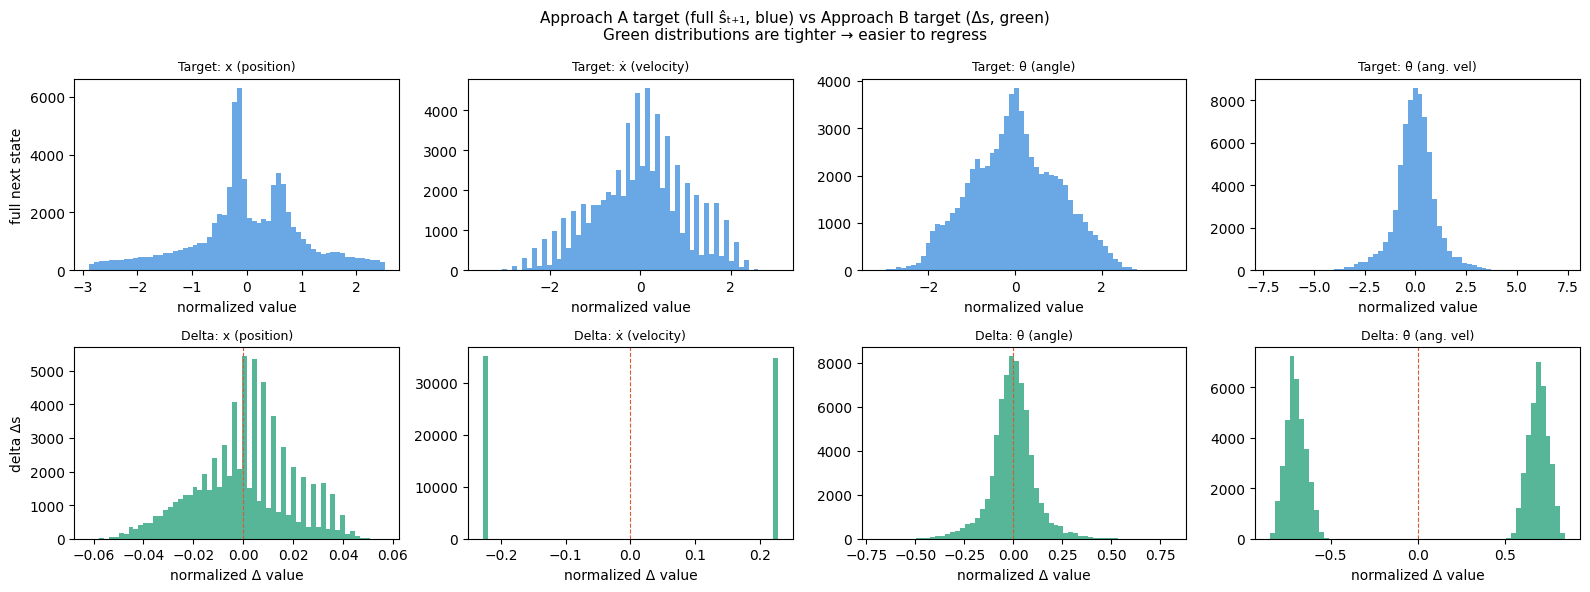


Target std comparison (lower = easier to predict):
  dim                    full next state std     delta std
  ----------------------------------------------------------
  x (position)                        1.0156        0.0190  ← easier
  ẋ (velocity)                        1.0115        0.2252  ← easier
  θ (angle)                           1.0143        0.1097  ← easier
  θ̇ (ang. vel)                       1.0135        0.6994  ← easier


In [4]:
dim_labels = ["x (position)", "ẋ (velocity)", "θ (angle)", "θ̇ (ang. vel)"]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, name in enumerate(dim_labels):
    # Row 0: full next state distribution
    axes[0, i].hist(sn_train[:, i].numpy(), bins=60, color="#378ADD", alpha=0.75, edgecolor="none")
    axes[0, i].set_title(f"Target: {name}", fontsize=9)
    axes[0, i].set_xlabel("normalized value")

    # Row 1: delta distribution — should be tight and centered near 0
    axes[1, i].hist(delta_train[:, i].numpy(), bins=60, color="#1D9E75", alpha=0.75, edgecolor="none")
    axes[1, i].set_title(f"Delta: {name}", fontsize=9)
    axes[1, i].set_xlabel("normalized Δ value")
    axes[1, i].axvline(0, color="#D85A30", linewidth=0.8, linestyle="--")

axes[0, 0].set_ylabel("full next state")
axes[1, 0].set_ylabel("delta Δs")

plt.suptitle(
    "Approach A target (full ŝₜ₊₁, blue) vs Approach B target (Δs, green)\n"
    "Green distributions are tighter → easier to regress",
    fontsize=11
)
plt.tight_layout()
plt.savefig("target_distributions.png", dpi=120)
plt.show()

print("\nTarget std comparison (lower = easier to predict):")
print(f"  {'dim':20s}  {'full next state std':>20}  {'delta std':>12}")
print("  " + "-" * 58)
for i, name in enumerate(dim_labels):
    fs = sn_train[:, i].std().item()
    ds = delta_train[:, i].std().item()
    print(f"  {name:20s}  {fs:20.4f}  {ds:12.4f}  {'← easier' if ds < fs else ''}")

---
## Cell 4 — DataLoaders

We build three separate `DataLoader` objects — one per approach — so training code is identical regardless of what the target is.

- **Approach A:** target = `sn` (full next state)
- **Approach B:** target = `delta` (sₜ₊₁ − sₜ)
- **Approach C:** target = `sn` (probabilistic head predicts μ and σ², trained with NLL)

In [5]:
BATCH_SIZE = 256

# Approach A — full next state
loader_A_train = DataLoader(
    TensorDataset(s_train, a_train, sn_train),
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=True
)
loader_A_val = DataLoader(
    TensorDataset(s_val, a_val, sn_val),
    batch_size=BATCH_SIZE, shuffle=False
)

# Approach B — delta prediction
loader_B_train = DataLoader(
    TensorDataset(s_train, a_train, delta_train),
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=True
)
loader_B_val = DataLoader(
    TensorDataset(s_val, a_val, delta_val),
    batch_size=BATCH_SIZE, shuffle=False
)

# Approach C — probabilistic (same data as A, different model output)
loader_C_train = DataLoader(
    TensorDataset(s_train, a_train, sn_train),
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=True
)
loader_C_val = DataLoader(
    TensorDataset(s_val, a_val, sn_val),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"Batch size  : {BATCH_SIZE}")
print(f"Train batches per epoch : {len(loader_A_train)}")
print(f"Val   batches           : {len(loader_A_val)}")

Batch size  : 256
Train batches per epoch : 273
Val   batches           : 40


---
## Cell 5 — Model Architecture

### Approach A & B — Deterministic MLP

```
Input  [6D] → Linear(6, 256) → ReLU → Linear(256, 256) → ReLU → Linear(256, 4) → Output [4D]
```

The only difference between A and B is what we **train it to output**:
- A: trains to predict $\hat{s}_{t+1}$ directly; at inference, output is used as-is.
- B: trains to predict $\hat{\Delta}$; at inference, add $s_t$ back: $\hat{s}_{t+1} = s_t + \hat{\Delta}$.

### Approach C — Probabilistic MLP

```
Input [6D] → shared trunk → split into two heads:
    μ-head    : Linear(256, 4)          → mean of next state
    log σ-head: Linear(256, 4) → clamp  → log variance (clamped for stability)
```

We output **log σ²** (not σ² directly) so the network can freely predict any value
and we `exp()` it to get a positive variance. Clamping prevents numerical explosion.

Loss = **Negative Log-Likelihood** of a Gaussian:
$$\mathcal{L} = \frac{1}{2} \sum_i \left[ \frac{(s^i_{t+1} - \mu^i)^2}{\sigma^{2,i}} + \log \sigma^{2,i} \right]$$
The model is penalized both for wrong mean predictions AND for being overconfident.

In [6]:
OBS_DIM    = 4
ACT_DIM    = 2
INPUT_DIM  = OBS_DIM + ACT_DIM   # 6
HIDDEN     = 256
OUTPUT_DIM = OBS_DIM              # 4


# ── Approach A & B: deterministic MLP ───────────────────────────────────────

class DeterministicPredictor(nn.Module):
    """
    3-layer MLP: [state (4) | one-hot action (2)] → next state or delta (4).

    Used for both:
      - Approach A: target = sₜ₊₁  (full next state)
      - Approach B: target = Δs    (delta)  ← recommended

    At inference for approach B: ŝₜ₊₁ = sₜ + model(sₜ, aₜ)

    Architecture notes:
      - ReLU: standard for regression, no saturation issues on unbounded output
      - Hidden size 256: large enough to capture CartPole dynamics, not overkill
      - Dropout 0.1: light regularization, prevents overfitting on 70k samples
      - No activation on output: we want unbounded regression values
    """
    def __init__(self, input_dim=INPUT_DIM, hidden=HIDDEN, output_dim=OUTPUT_DIM, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, output_dim),
        )

    def forward(self, state, action_oh):
        """
        state     : (batch, 4)  — normalized current state
        action_oh : (batch, 2)  — one-hot encoded action
        Returns   : (batch, 4)  — predicted next state OR predicted delta
        """
        x = torch.cat([state, action_oh], dim=-1)   # (batch, 6)
        return self.net(x)                            # (batch, 4)


# ── Approach C: probabilistic MLP ───────────────────────────────────────────

class ProbabilisticPredictor(nn.Module):
    """
    Shared trunk → two heads: μ (mean) and log σ² (log variance).

    Output at inference:
      - mu    : (batch, 4) — predicted mean of next state
      - sigma2: (batch, 4) — predicted variance (always positive)

    High sigma2 in a dimension = the model is uncertain about that dimension.
    Used in Step 4 for action gating: reject actions where sigma2 > threshold.

    Why log σ²?
      exp(log σ²) is always positive — we get a valid variance even if the
      network outputs negative numbers. Clamping prevents numerical explosion.
    """
    LOG_VAR_MIN = -10.0   # exp(-10) ≈ 4.5e-5  (very confident)
    LOG_VAR_MAX =  4.0    # exp(4)   ≈ 54.6    (very uncertain)

    def __init__(self, input_dim=INPUT_DIM, hidden=HIDDEN, output_dim=OUTPUT_DIM, dropout=0.1):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden,    hidden), nn.ReLU(), nn.Dropout(dropout),
        )
        self.mu_head      = nn.Linear(hidden, output_dim)   # mean
        self.log_var_head = nn.Linear(hidden, output_dim)   # log variance

    def forward(self, state, action_oh):
        """
        Returns (mu, sigma2) — both shape (batch, 4).
        sigma2 is the variance (not std), clamped to a safe range.
        """
        x       = torch.cat([state, action_oh], dim=-1)
        h       = self.trunk(x)
        mu      = self.mu_head(h)
        log_var = self.log_var_head(h).clamp(self.LOG_VAR_MIN, self.LOG_VAR_MAX)
        sigma2  = torch.exp(log_var)
        return mu, sigma2


# ── Quick parameter count ────────────────────────────────────────────────────
det_model  = DeterministicPredictor().to(DEVICE)
prob_model = ProbabilisticPredictor().to(DEVICE)

n_det  = sum(p.numel() for p in det_model.parameters())
n_prob = sum(p.numel() for p in prob_model.parameters())

print(f"DeterministicPredictor  params : {n_det:,}")
print(f"ProbabilisticPredictor  params : {n_prob:,}")

# Sanity-check forward pass
dummy_s = torch.zeros(4, 4).to(DEVICE)
dummy_a = torch.zeros(4, 2).to(DEVICE)
out_det  = det_model(dummy_s, dummy_a)
mu, sig2 = prob_model(dummy_s, dummy_a)
print(f"\nDeterministic output shape : {out_det.shape}   ← (batch=4, 4 state dims)")
print(f"Probabilistic mu shape     : {mu.shape}")
print(f"Probabilistic sigma2 shape : {sig2.shape}")

DeterministicPredictor  params : 68,612
ProbabilisticPredictor  params : 69,640

Deterministic output shape : torch.Size([4, 4])   ← (batch=4, 4 state dims)
Probabilistic mu shape     : torch.Size([4, 4])
Probabilistic sigma2 shape : torch.Size([4, 4])


---
## Cell 6 — Loss Functions

Three losses, one per approach:

| Approach | Loss | Notes |
|---|---|---|
| A | MSE | Baseline. Sensitive to outliers. |
| B | **Huber** | Behaves as MSE for small errors, L1 for large. Robust to outlier transitions. |
| C | **Gaussian NLL** | Penalizes wrong mean AND wrong confidence. |

**Weighted MSE** (also implemented below) multiplies per-dimension errors by weights
inversely proportional to that dimension's variance. This prevents the high-variance
`θ̇` dimension from dominating the loss and causing the model to ignore `x` and `θ`.

In [7]:
# ── Approach A: MSE ──────────────────────────────────────────────────────────

def mse_loss(pred, target):
    """Standard mean squared error. Shape-agnostic."""
    return F.mse_loss(pred, target)


# ── Approach B: Huber (recommended) ─────────────────────────────────────────

def huber_loss(pred, target, delta=1.0):
    """
    Huber loss (also called SmoothL1 in PyTorch).

    For |error| < delta : 0.5 * error²          ← like MSE, very precise
    For |error| ≥ delta : delta * |error| - 0.5  ← like L1, doesn't explode

    delta=1.0 is a good default for normalized data (values in [-3, 3]).
    """
    return F.huber_loss(pred, target, delta=delta)


# ── Approach B variant: Weighted MSE ────────────────────────────────────────

def weighted_mse_loss(pred, target, weights):
    """
    Per-dimension weighted MSE.

    weights : (4,) tensor — one weight per state dimension.
    Typically set to 1 / variance of each target dimension,
    so high-variance dims (θ̇) don't dominate the loss.

    Example:
        target_var = delta_train.var(dim=0)      # shape (4,)
        weights    = 1.0 / (target_var + 1e-8)   # shape (4,)
        weights    = weights / weights.sum()      # normalize to sum=1
    """
    per_dim = ((pred - target) ** 2).mean(dim=0)   # (4,) — one loss per dim
    return (per_dim * weights).sum()


# ── Approach C: Gaussian Negative Log-Likelihood ─────────────────────────────

def gaussian_nll_loss(mu, sigma2, target):
    """
    Negative log-likelihood of a diagonal Gaussian:
        L = 0.5 * sum_i [ (target_i - mu_i)² / σ²_i  +  log σ²_i ]

    The second term log σ²_i penalizes the model for claiming certainty
    when its mean prediction is still imprecise — prevents σ²→∞ collapse.

    PyTorch has F.gaussian_nll_loss which does the same thing:
        F.gaussian_nll_loss(mu, target, sigma2, full=False)
    We implement it manually here for clarity.
    """
    squared_error = (target - mu) ** 2
    loss = 0.5 * (squared_error / sigma2 + torch.log(sigma2))
    return loss.mean()


# ── Compute per-dim weights for Weighted MSE ────────────────────────────────
target_var   = delta_train.var(dim=0)          # shape (4,)
dim_weights  = 1.0 / (target_var + 1e-8)
dim_weights  = (dim_weights / dim_weights.sum()).to(DEVICE)

print("Per-dimension weights for Weighted MSE (higher = more emphasis):")
for i, (name, w) in enumerate(zip(dim_labels, dim_weights.cpu())):
    print(f"  {name:20s}  var={target_var[i]:.5f}  weight={w:.4f}")

Per-dimension weights for Weighted MSE (higher = more emphasis):
  x (position)          var=0.00036  weight=0.9634
  ẋ (velocity)          var=0.05074  weight=0.0069
  θ (angle)             var=0.01204  weight=0.0290
  θ̇ (ang. vel)         var=0.48919  weight=0.0007


---
## Cell 7 — Training Loop (generic)

One reusable function that trains any predictor (deterministic or probabilistic)
with any loss function. It:
- Runs for `n_epochs` with Adam optimizer and cosine LR schedule
- Logs train loss and val loss every epoch
- Computes **per-dimension val MSE** at the end — the main comparison metric
- Saves the best checkpoint based on val loss
- Returns the history dict for plotting

In [8]:
def train_predictor(
    model,
    train_loader,
    val_loader,
    loss_fn,          # callable(pred_or_mu, target) or (mu, sigma2, target) for prob
    model_name,       # string label for printing and saving
    is_probabilistic=False,
    n_epochs=80,
    lr=3e-4,
    save_best=True,
):
    """
    Generic training loop for all three predictor approaches.

    Parameters
    ----------
    model            : nn.Module (Deterministic or Probabilistic)
    train_loader     : DataLoader yielding (state, action_oh, target)
    val_loader       : DataLoader yielding (state, action_oh, target)
    loss_fn          : loss function
    model_name       : used for print statements and checkpoint filename
    is_probabilistic : if True, model returns (mu, sigma2) and loss_fn
                       must accept (mu, sigma2, target)
    n_epochs         : training epochs
    lr               : Adam initial learning rate
    save_best        : save checkpoint at lowest val loss

    Returns
    -------
    history : dict with keys 'train_loss', 'val_loss'
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Cosine annealing: lr decays smoothly from lr → 0 over n_epochs
    # Prevents overshooting in later epochs without needing manual LR drops
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history    = {"train_loss": [], "val_loss": []}
    best_val   = float("inf")
    best_path  = f"{model_name}_best.pth"

    print(f"\n{'='*60}")
    print(f"Training: {model_name}   ({n_epochs} epochs, lr={lr})")
    print(f"{'='*60}")

    for epoch in range(1, n_epochs + 1):

        # ── Train phase ───────────────────────────────────────────────────
        model.train()
        train_losses = []
        for s_b, a_b, tgt_b in train_loader:
            s_b, a_b, tgt_b = s_b.to(DEVICE), a_b.to(DEVICE), tgt_b.to(DEVICE)

            if is_probabilistic:
                mu, sigma2 = model(s_b, a_b)
                loss = loss_fn(mu, sigma2, tgt_b)
            else:
                pred = model(s_b, a_b)
                loss = loss_fn(pred, tgt_b)

            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping: prevents exploding gradients in early training
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        scheduler.step()

        # ── Validation phase ──────────────────────────────────────────────
        model.eval()
        val_losses = []
        with torch.no_grad():
            for s_b, a_b, tgt_b in val_loader:
                s_b, a_b, tgt_b = s_b.to(DEVICE), a_b.to(DEVICE), tgt_b.to(DEVICE)

                if is_probabilistic:
                    mu, sigma2 = model(s_b, a_b)
                    loss = loss_fn(mu, sigma2, tgt_b)
                else:
                    pred = model(s_b, a_b)
                    loss = loss_fn(pred, tgt_b)

                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Save best checkpoint
        if save_best and val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), best_path)

        if epoch % 10 == 0 or epoch == 1:
            lr_now = scheduler.get_last_lr()[0]
            print(f"  Epoch {epoch:>3}/{n_epochs}  "
                  f"train={train_loss:.5f}  val={val_loss:.5f}  "
                  f"lr={lr_now:.2e}  "
                  f"{'* best' if val_loss == best_val else ''}")

    print(f"\nBest val loss: {best_val:.5f}  →  saved to {best_path}")
    return history


print("Training loop defined. Ready to train all three approaches.")

Training loop defined. Ready to train all three approaches.


---
## Cell 8 — Train Approach A: Full next state prediction with MSE

Baseline. Predict $\hat{s}_{t+1}$ directly, minimize MSE.

In [9]:
model_A   = DeterministicPredictor().to(DEVICE)
history_A = train_predictor(
    model      = model_A,
    train_loader = loader_A_train,
    val_loader   = loader_A_val,
    loss_fn      = mse_loss,
    model_name   = "approach_A_full_mse",
    n_epochs     = 80,
    lr           = 3e-4,
)


Training: approach_A_full_mse   (80 epochs, lr=0.0003)
  Epoch   1/80  train=0.07612  val=0.00098  lr=3.00e-04  * best
  Epoch  10/80  train=0.00611  val=0.00040  lr=2.89e-04  
  Epoch  20/80  train=0.00544  val=0.00033  lr=2.56e-04  
  Epoch  30/80  train=0.00497  val=0.00050  lr=2.07e-04  
  Epoch  40/80  train=0.00482  val=0.00038  lr=1.50e-04  
  Epoch  50/80  train=0.00471  val=0.00021  lr=9.26e-05  
  Epoch  60/80  train=0.00463  val=0.00015  lr=4.39e-05  
  Epoch  70/80  train=0.00459  val=0.00014  lr=1.14e-05  
  Epoch  80/80  train=0.00460  val=0.00012  lr=0.00e+00  

Best val loss: 0.00009  →  saved to approach_A_full_mse_best.pth


---
## Cell 9 — Train Approach B: Delta prediction with Huber loss (recommended)

The model predicts $\hat{\Delta} = \hat{s}_{t+1} - s_t$.
At inference, we reconstruct: $\hat{s}_{t+1} = s_t + \hat{\Delta}$.

In [10]:
model_B   = DeterministicPredictor().to(DEVICE)
history_B = train_predictor(
    model        = model_B,
    train_loader = loader_B_train,
    val_loader   = loader_B_val,
    loss_fn      = huber_loss,
    model_name   = "approach_B_delta_huber",
    n_epochs     = 80,
    lr           = 3e-4,
)


Training: approach_B_delta_huber   (80 epochs, lr=0.0003)
  Epoch   1/80  train=0.00449  val=0.00005  lr=3.00e-04  * best
  Epoch  10/80  train=0.00020  val=0.00006  lr=2.89e-04  
  Epoch  20/80  train=0.00011  val=0.00001  lr=2.56e-04  
  Epoch  30/80  train=0.00010  val=0.00001  lr=2.07e-04  
  Epoch  40/80  train=0.00010  val=0.00001  lr=1.50e-04  
  Epoch  50/80  train=0.00010  val=0.00000  lr=9.26e-05  
  Epoch  60/80  train=0.00009  val=0.00000  lr=4.39e-05  * best
  Epoch  70/80  train=0.00009  val=0.00000  lr=1.14e-05  
  Epoch  80/80  train=0.00009  val=0.00000  lr=0.00e+00  

Best val loss: 0.00000  →  saved to approach_B_delta_huber_best.pth


---
## Cell 10 — Train Approach C: Probabilistic predictor with NLL

Predicts $\mu$ and $\sigma^2$ for each state dimension.
The uncertainty $\sigma^2$ will be used in Step 4 for action gating.

In [11]:
model_C   = ProbabilisticPredictor().to(DEVICE)
history_C = train_predictor(
    model            = model_C,
    train_loader     = loader_C_train,
    val_loader       = loader_C_val,
    loss_fn          = gaussian_nll_loss,
    model_name       = "approach_C_probabilistic_nll",
    is_probabilistic = True,
    n_epochs         = 80,
    lr               = 3e-4,
)


Training: approach_C_probabilistic_nll   (80 epochs, lr=0.0003)
  Epoch   1/80  train=-0.93487  val=-1.91477  lr=3.00e-04  * best
  Epoch  10/80  train=-2.17223  val=-2.64083  lr=2.89e-04  * best
  Epoch  20/80  train=-2.28119  val=-2.76040  lr=2.56e-04  * best
  Epoch  30/80  train=-2.34160  val=-2.82801  lr=2.07e-04  * best
  Epoch  40/80  train=-2.37927  val=-2.82983  lr=1.50e-04  
  Epoch  50/80  train=-2.40909  val=-2.87902  lr=9.26e-05  
  Epoch  60/80  train=-2.42983  val=-2.87784  lr=4.39e-05  
  Epoch  70/80  train=-2.43602  val=-2.90093  lr=1.14e-05  
  Epoch  80/80  train=-2.43613  val=-2.90830  lr=0.00e+00  

Best val loss: -2.91773  →  saved to approach_C_probabilistic_nll_best.pth


---
## Cell 11 — Plot training curves

Compare train and val loss curves for all three approaches.
Look for:
- **Overfitting signal:** val loss diverges upward from train loss → add dropout or reduce epochs
- **Convergence:** loss plateaus → training is done, more epochs won't help
- **B should converge faster than A** because deltas are easier to regress

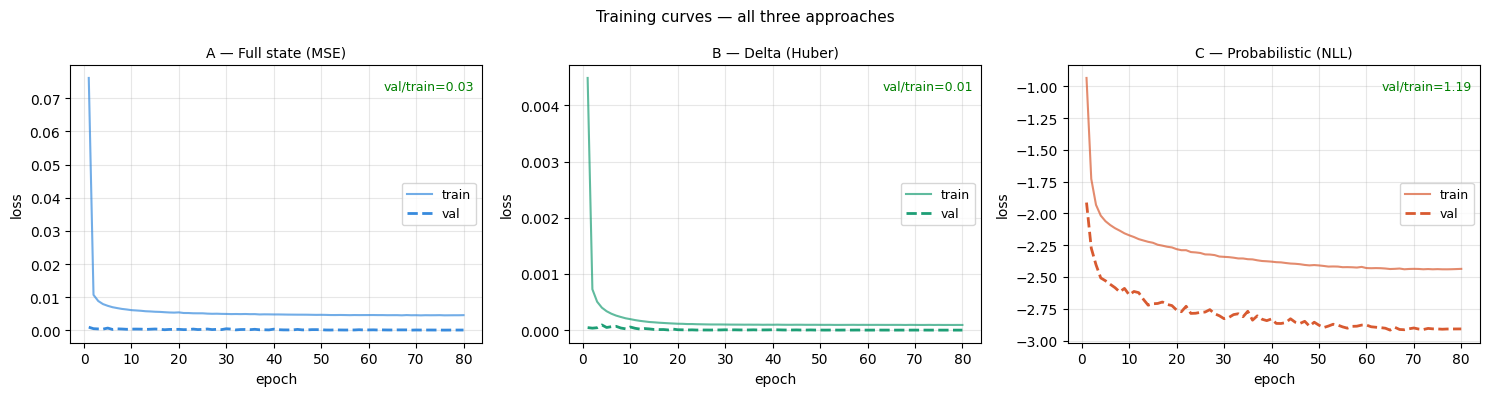

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (history_A, "A — Full state (MSE)",   "#378ADD"),
    (history_B, "B — Delta (Huber)",      "#1D9E75"),
    (history_C, "C — Probabilistic (NLL)","#D85A30"),
]

for ax, (hist, title, color) in zip(axes, configs):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs, hist["train_loss"], color=color,   lw=1.5,  alpha=0.7, label="train")
    ax.plot(epochs, hist["val_loss"],   color=color,   lw=2.0,  linestyle="--", label="val")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Overfit ratio: val/train > 2 is a red flag
    final_ratio = hist["val_loss"][-1] / (hist["train_loss"][-1] + 1e-9)
    color_ratio = "red" if final_ratio > 2.0 else "green"
    ax.text(0.98, 0.95, f"val/train={final_ratio:.2f}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color=color_ratio)

plt.suptitle("Training curves — all three approaches", fontsize=11)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

---
## Cell 12 — Per-dimension val MSE comparison

The most important evaluation: **how accurate is the prediction per state dimension?**

For all three approaches we compute the reconstructed $\hat{s}_{t+1}$ in **normalized space**
and measure MSE per dimension. Lower = better.

Approach B reconstruction: `pred_sn = s_val + model_B(s_val, a_val)` (add delta back).

Per-dimension val MSE (lower is better)
  Dimension               A (full+MSE)   B (delta+Huber)   C (prob+NLL)    winner
  --------------------------------------------------------------------------------
  x (position)                0.000105          0.000003       0.000131         B
  ẋ (velocity)                0.000086          0.000001       0.000120         B
  θ (angle)                   0.000105          0.000002       0.000128         B
  θ̇ (ang. vel)               0.000080          0.000002       0.000114         B

  MEAN                        0.000094          0.000002       0.000123


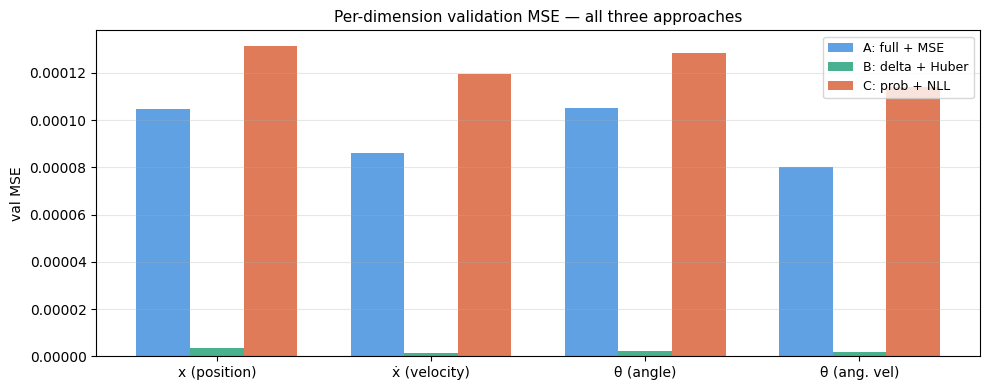

In [13]:
def per_dim_mse(model, s, a, sn_true, is_delta=False, is_prob=False, device=DEVICE):
    """
    Compute per-dimension MSE between predicted and true next state.

    For delta models (is_delta=True): pred_sn = s + model(s, a)
    For probabilistic models (is_prob=True): use mu output

    Returns: (4,) numpy array of MSE values, one per state dimension
    """
    model.eval()
    s_d, a_d, sn_d = s.to(device), a.to(device), sn_true.to(device)

    with torch.no_grad():
        if is_prob:
            mu, _ = model(s_d, a_d)
            pred_sn = mu
        elif is_delta:
            delta_pred = model(s_d, a_d)
            pred_sn    = s_d + delta_pred     # reconstruct next state
        else:
            pred_sn = model(s_d, a_d)

    mse_per_dim = ((pred_sn - sn_d) ** 2).mean(dim=0).cpu().numpy()
    return mse_per_dim


# Load best checkpoints for fair comparison
model_A.load_state_dict(torch.load("approach_A_full_mse_best.pth",      map_location=DEVICE))
model_B.load_state_dict(torch.load("approach_B_delta_huber_best.pth",   map_location=DEVICE))
model_C.load_state_dict(torch.load("approach_C_probabilistic_nll_best.pth", map_location=DEVICE))

mse_A = per_dim_mse(model_A, s_val, a_val, sn_val, is_delta=False, is_prob=False)
mse_B = per_dim_mse(model_B, s_val, a_val, sn_val, is_delta=True,  is_prob=False)
mse_C = per_dim_mse(model_C, s_val, a_val, sn_val, is_delta=False, is_prob=True)

print("Per-dimension val MSE (lower is better)")
print(f"  {'Dimension':20s}  {'A (full+MSE)':>14}  {'B (delta+Huber)':>16}  {'C (prob+NLL)':>13}  {'winner':>8}")
print("  " + "-" * 80)
for i, name in enumerate(dim_labels):
    best = min(mse_A[i], mse_B[i], mse_C[i])
    winner = ["A", "B", "C"][[mse_A[i], mse_B[i], mse_C[i]].index(best)]
    print(f"  {name:20s}  {mse_A[i]:14.6f}  {mse_B[i]:16.6f}  {mse_C[i]:13.6f}  {winner:>8}")

print(f"\n  {'MEAN':20s}  {mse_A.mean():14.6f}  {mse_B.mean():16.6f}  {mse_C.mean():13.6f}")

# Bar chart
x    = np.arange(len(dim_labels))
w    = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w,  mse_A, w, label="A: full + MSE",   color="#378ADD", alpha=0.8)
ax.bar(x,      mse_B, w, label="B: delta + Huber", color="#1D9E75", alpha=0.8)
ax.bar(x + w,  mse_C, w, label="C: prob + NLL",    color="#D85A30", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylabel("val MSE")
ax.set_title("Per-dimension validation MSE — all three approaches", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_dim_mse.png", dpi=120)
plt.show()

---
## Cell 13 — Residual analysis

Plot **predicted vs true** for the best model (expected: approach B) on the val set.
A perfect predictor gives points on the diagonal $y = x$.
Systematic deviation from the diagonal = **bias** in specific state regions.

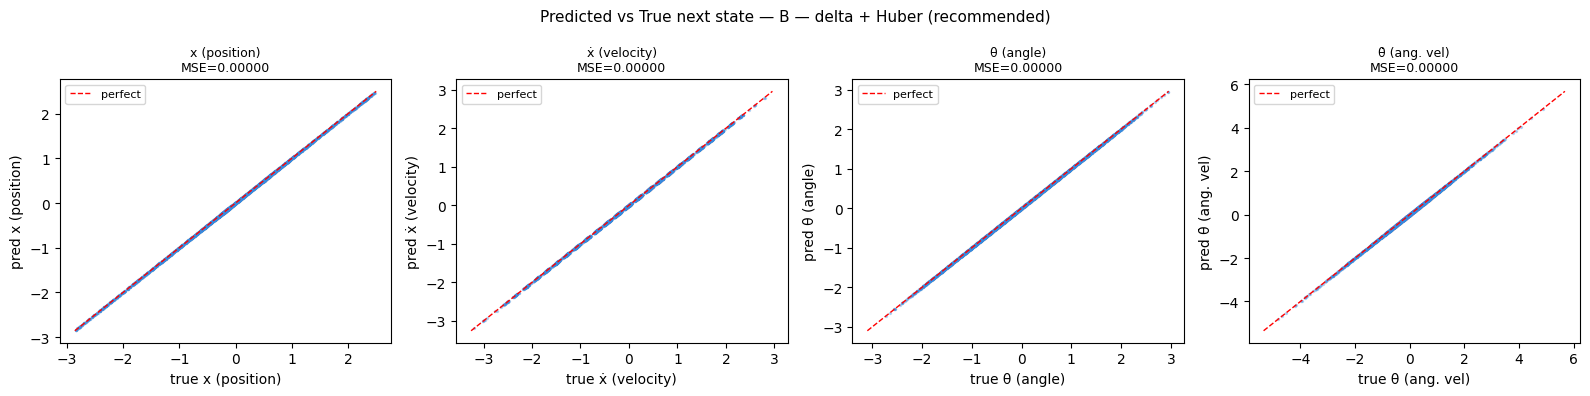

In [14]:
# Use the best model (update this if A or C wins above)
best_model   = model_B
best_name    = "B — delta + Huber (recommended)"
use_delta    = True

best_model.eval()
with torch.no_grad():
    if use_delta:
        delta_pred   = best_model(s_val.to(DEVICE), a_val.to(DEVICE)).cpu()
        sn_pred      = s_val + delta_pred
    else:
        sn_pred = best_model(s_val.to(DEVICE), a_val.to(DEVICE)).cpu()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, name) in enumerate(zip(axes, dim_labels)):
    true = sn_val[:, i].numpy()
    pred = sn_pred[:, i].numpy()

    # Sample 3000 points for readability
    idx = np.random.choice(len(true), 3000, replace=False)
    ax.scatter(true[idx], pred[idx], s=2, alpha=0.3, color="#378ADD")

    # Perfect prediction line
    lo, hi = min(true.min(), pred.min()), max(true.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.0, label="perfect")

    ax.set_xlabel(f"true {name}"); ax.set_ylabel(f"pred {name}")
    ax.set_title(f"{name}\nMSE={mse_B[i]:.5f}", fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle(f"Predicted vs True next state — {best_name}", fontsize=11)
plt.tight_layout()
plt.savefig("residuals.png", dpi=120)
plt.show()

---
## Cell 14 — Uncertainty visualization (Approach C only)

For the probabilistic model, plot the **predicted uncertainty $\sigma^2$** vs the **actual squared error**.

A well-calibrated model: high $\sigma^2$ should correlate with high actual error.
If they don't correlate, the model is overconfident or underconfident — not useful for gating.

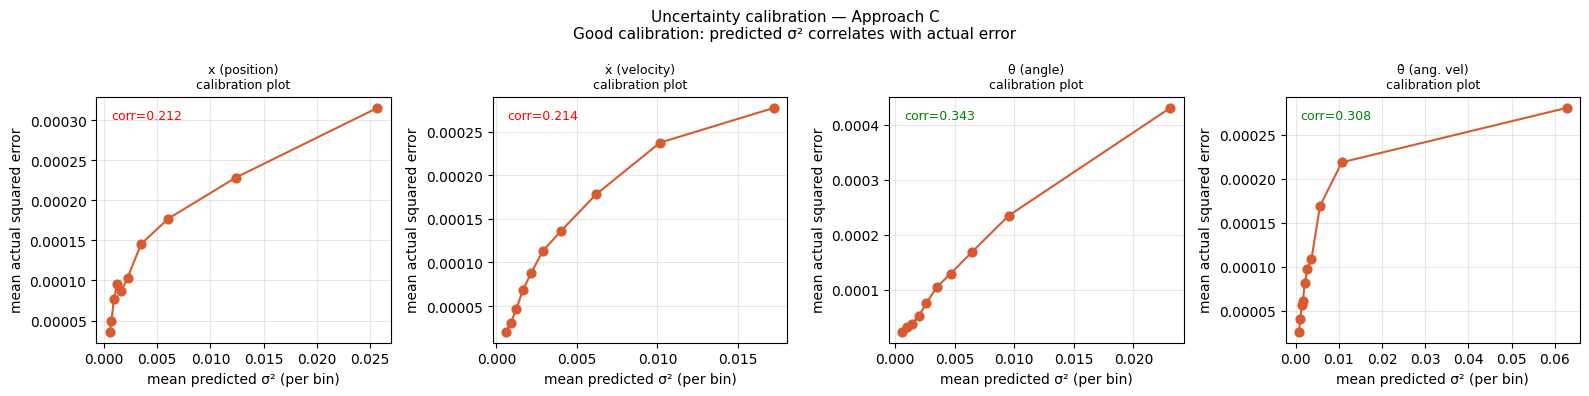

In [15]:
model_C.eval()
with torch.no_grad():
    mu_val, sigma2_val = model_C(s_val.to(DEVICE), a_val.to(DEVICE))
    mu_val    = mu_val.cpu()
    sigma2_val = sigma2_val.cpu()

actual_sq_err = (sn_val - mu_val) ** 2    # shape (N, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, name) in enumerate(zip(axes, dim_labels)):
    sig2   = sigma2_val[:, i].numpy()
    sq_err = actual_sq_err[:, i].numpy()

    # Bin sigma2 into deciles and show mean actual error per bin
    bins    = np.percentile(sig2, np.linspace(0, 100, 11))
    bin_ids = np.digitize(sig2, bins[:-1]) - 1
    bin_ids = np.clip(bin_ids, 0, 9)
    bin_means_sig  = [sig2[bin_ids == b].mean()   for b in range(10)]
    bin_means_err  = [sq_err[bin_ids == b].mean() for b in range(10)]

    ax.scatter(bin_means_sig, bin_means_err, s=40, color="#D85A30", zorder=5)
    ax.plot(bin_means_sig,    bin_means_err, color="#D85A30", lw=1.5)

    ax.set_xlabel("mean predicted σ² (per bin)")
    ax.set_ylabel("mean actual squared error")
    ax.set_title(f"{name}\ncalibration plot", fontsize=9)
    ax.grid(alpha=0.3)

    # Pearson correlation
    corr = np.corrcoef(sig2, sq_err)[0, 1]
    ax.text(0.05, 0.95, f"corr={corr:.3f}",
            transform=ax.transAxes, fontsize=9,
            color="green" if corr > 0.3 else "red", va="top")

plt.suptitle(
    "Uncertainty calibration — Approach C\n"
    "Good calibration: predicted σ² correlates with actual error",
    fontsize=11
)
plt.tight_layout()
plt.savefig("uncertainty_calibration.png", dpi=120)
plt.show()

---
## Cell 15 — Save the best predictor + normalization stats

We save:
1. **`predictor.pth`** — the best model weights (approach B by default, update if C wins)
2. **`norm_stats.npz`** — mean and std from the training set, needed to normalize
   incoming states in the RL loop (Step 4) and de-normalize predictions back to real units
3. **`predictor_config.pt`** — model config dict so we can re-instantiate without hard-coding

In the RL loop (Step 4), the predictor will be used as follows:
```python
# Normalize incoming state
s_norm = (s_raw - mean) / std
# Predict in normalized space
delta_pred = predictor(s_norm, a_onehot)
sn_norm    = s_norm + delta_pred
# De-normalize back to CartPole units
sn_raw     = sn_norm * std + mean
```

In [16]:
# ── Decide which model to save as 'the' predictor ───────────────────────────
# Change this to model_C + is_delta=False + is_prob=True if C performed best
BEST_APPROACH = "B"   # "A", "B", or "C"

approach_map = {
    "A": (model_A, "approach_A_full_mse_best.pth",           False, False),
    "B": (model_B, "approach_B_delta_huber_best.pth",        True,  False),
    "C": (model_C, "approach_C_probabilistic_nll_best.pth",  False, True),
}
chosen_model, chosen_ckpt, chosen_delta, chosen_prob = approach_map[BEST_APPROACH]

# Load the best checkpoint of the chosen approach
chosen_model.load_state_dict(torch.load(chosen_ckpt, map_location=DEVICE))
chosen_model.eval()

# Save predictor weights
torch.save(chosen_model.state_dict(), "predictor.pth")

# Save model config for re-instantiation in Step 4
config = {
    "approach":        BEST_APPROACH,
    "is_delta":        chosen_delta,
    "is_probabilistic":chosen_prob,
    "input_dim":       INPUT_DIM,
    "hidden":          HIDDEN,
    "output_dim":      OUTPUT_DIM,
    "obs_dim":         OBS_DIM,
    "act_dim":         ACT_DIM,
}
torch.save(config, "predictor_config.pt")

# Save normalization stats
np.savez("norm_stats.npz",
         mean=MEAN.numpy(),
         std=STD.numpy())

print("Files saved:")
print(f"  predictor.pth        ← approach {BEST_APPROACH} weights")
print( "  predictor_config.pt  ← model config dict")
print( "  norm_stats.npz       ← mean and std for de-normalization")
print()
print("Config:")
for k, v in config.items():
    print(f"  {k:22s}: {v}")
print()
print("Usage in Step 4 (RL loop):")
print("  config    = torch.load('predictor_config.pt')")
print("  if config['is_probabilistic']:")
print("      model = ProbabilisticPredictor(...)")
print("  else:")
print("      model = DeterministicPredictor(...)")
print("  model.load_state_dict(torch.load('predictor.pth'))")
print("  model.eval()  # freeze — never train during RL loop")

Files saved:
  predictor.pth        ← approach B weights
  predictor_config.pt  ← model config dict
  norm_stats.npz       ← mean and std for de-normalization

Config:
  approach              : B
  is_delta              : True
  is_probabilistic      : False
  input_dim             : 6
  hidden                : 256
  output_dim            : 4
  obs_dim               : 4
  act_dim               : 2

Usage in Step 4 (RL loop):
  config    = torch.load('predictor_config.pt')
  if config['is_probabilistic']:
      model = ProbabilisticPredictor(...)
  else:
      model = DeterministicPredictor(...)
  model.load_state_dict(torch.load('predictor.pth'))
  model.eval()  # freeze — never train during RL loop


---
## Cell 16 — Summary

Print a final comparison table and confirm readiness for Step 3.

In [17]:
print("=" * 65)
print("STEP 2 SUMMARY — DNN Predictor")
print("=" * 65)

print(f"\n{'Approach':<35} {'Mean val MSE':>14}  {'Winner per dim'}")
print("-" * 65)

results = [
    ("A — full next state + MSE",    mse_A),
    ("B — delta + Huber (recommended)", mse_B),
    ("C — probabilistic + NLL",       mse_C),
]

all_mse = np.stack([mse_A, mse_B, mse_C])  # (3, 4)
winners = all_mse.argmin(axis=0)            # (4,) — index of best approach per dim
win_labels = ["A", "B", "C"]

for j, (name, mse) in enumerate(results):
    won = [win_labels[j] if winners[i] == j else "  " for i in range(4)]
    won_str = "  ".join(f"{d}: {w}" for d, w in zip(["x","ẋ","θ","θ̇"], won))
    print(f"{name:<35} {mse.mean():14.6f}  {won_str}")

print(f"\nSaved predictor : approach {BEST_APPROACH}")
print(f"Output files    : predictor.pth | predictor_config.pt | norm_stats.npz")
print()
print("Next: Step 3 — Predictor evaluation (rollout accuracy, residual analysis)")
print("Then: Step 4 — Plug predictor into RL loop as a precedence gate")

STEP 2 SUMMARY — DNN Predictor

Approach                              Mean val MSE  Winner per dim
-----------------------------------------------------------------
A — full next state + MSE                 0.000094  x:     ẋ:     θ:     θ̇:   
B — delta + Huber (recommended)           0.000002  x: B  ẋ: B  θ: B  θ̇: B
C — probabilistic + NLL                   0.000123  x:     ẋ:     θ:     θ̇:   

Saved predictor : approach B
Output files    : predictor.pth | predictor_config.pt | norm_stats.npz

Next: Step 3 — Predictor evaluation (rollout accuracy, residual analysis)
Then: Step 4 — Plug predictor into RL loop as a precedence gate
